In [55]:
# Cell 1: Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from dataclasses import dataclass
import random
import heapq

#CONSTANTS
MAX_WALK = 12 # Maximum walking amount of 12 minutes
PRICE_WEIGHT = 2.0 # Every dollar for the parking lot price = 2 minutes

In [56]:
# Cell 2: Graph Definition

# Directed graph with travel times
TRAVEL_TIMES = {
    ('S', 'A'): 4,
    ('S', 'B'): 6,
    ('A', 'E'): 8,
    ('A', 'C'): 4,
    ('B', 'C'): 2,
    ('B', 'E'): 4,
    ('E', 'D'): 2,
    ('C', 'D'): 6
}

# adjacency list
ADJ = defaultdict(list)
for (u, v), cost in TRAVEL_TIMES.items():
    ADJ[u].append(v)

START = 'S'
DESTINATION = 'D' 

In [57]:
# Cell 3: Parking Lot Definition and RL environment logic

LOTS = {
    'A': {'price': 5, 'walk_min': 15, 'capacity': 10, 'occupied': 7},
    'B': {'price': 3, 'walk_min': 20, 'capacity': 10, 'occupied': 10},
    'C': {'price': 4, 'walk_min': 10, 'capacity': 10, 'occupied': 2},
    'E': {'price': 10, 'walk_min': 5, 'capacity': 10, 'occupied': 9}
}

print(LOTS)

{'A': {'price': 5, 'walk_min': 15, 'capacity': 10, 'occupied': 7}, 'B': {'price': 3, 'walk_min': 20, 'capacity': 10, 'occupied': 10}, 'C': {'price': 4, 'walk_min': 10, 'capacity': 10, 'occupied': 2}, 'E': {'price': 10, 'walk_min': 5, 'capacity': 10, 'occupied': 9}}


In [58]:
# Cell 4: Functions for RL environment

def lot_valid(lot):
    return (
        LOTS[lot]['occupied'] < LOTS[lot]['capacity']
        and LOTS[lot]['walk_min'] <= MAX_WALK
    )

def total_cost(travel_cost, lot):
    return travel_cost + LOTS[lot]['price'] * PRICE_WEIGHT + LOTS[lot]['walk_min']

for lot in LOTS:
    print(lot, "valid =", lot_valid(lot))

A valid = False
B valid = False
C valid = True
E valid = True


In [59]:
# Cell 5: Shortest path calculation 

def shortest_path_cost(start, goal):
    pq = [(0, start)]
    visited = set()

    while pq:
        cost, node = heapq.heappop(pq)

        if node == goal:
            return cost

        if node in visited:
            continue
        visited.add(node)

        for neighbor in ADJ[node]:
            edge_cost = TRAVEL_TIMES[(node, neighbor)]
            heapq.heappush(pq, (cost + edge_cost, neighbor))

    return float('inf')

In [60]:
# Cell 6: Baseline evaluation of parking lots

def baseline_best_lot():
    best_lot = None
    best_score = float('inf')

    for lot in LOTS:
        if lot_valid(lot):
            drive_cost = shortest_path_cost(START, lot)
            score = total_cost(drive_cost, lot)

            print(f"Lot {lot}: drive={drive_cost}, total score={score}")

            if score < best_score:
                best_score = score
                best_lot = lot

    return best_lot, best_score

result = baseline_best_lot()
print("\nBest lot:", result[0])
print("Best score:", result[1])

Lot C: drive=8, total score=26.0
Lot E: drive=10, total score=35.0

Best lot: C
Best score: 26.0


Q-Learning

In [61]:
# Cell 7: Q-learning setup

states = list(set([u for u, v in TRAVEL_TIMES] + [v for u, v in TRAVEL_TIMES]))
actions = {state: ADJ[state] for state in ADJ}

Q = {
    state: {action: 0.0 for action in actions.get(state, [])}
    for state in states
}

alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 500

In [62]:
# Cell 8: Reward function for RL

def get_reward(current, next_node):
    travel_penalty = -TRAVEL_TIMES[(current, next_node)]

    # parking lot reached
    if next_node in LOTS:
        if lot_valid(next_node):
            # strong positive terminal reward
            success_reward = 100

            cost_penalty = (
                LOTS[next_node]['price']
                + LOTS[next_node]['walk_min']
            )

            return success_reward - cost_penalty + travel_penalty

        else:
            return -100

    return travel_penalty

In [63]:
# Cell 9: Q-learning Training Loop

def train_q_learning(episodes=500):
    global Q, reward_history

    # reset Q-table each time we retrain
    Q = {
        state: {action: 0.0 for action in actions.get(state, [])}
        for state in states
    }

    reward_history = []

    for episode in range(episodes):
        state = START
        total_episode_reward = 0

        while state in actions:
            # epsilon-greedy action selection
            if random.random() < epsilon:
                action = random.choice(actions[state])
            else:
                action = max(Q[state], key=Q[state].get)

            reward = get_reward(state, action)
            total_episode_reward += reward

            next_state = action

            if next_state in actions and len(Q[next_state]) > 0:
                max_future_q = max(Q[next_state].values())
            else:
                max_future_q = 0

            Q[state][action] += alpha * (
                reward + gamma * max_future_q - Q[state][action]
            )

            if next_state in LOTS and lot_valid(next_state):
                break

            state = next_state

        reward_history.append(total_episode_reward)

In [64]:
# Cell 10: Retrain model and print learned Q-values

train_q_learning()

# print learned Q-values
print("Learned Q-table:")
for state in Q:
    print(state, Q[state])

Learned Q-table:
S {'A': -26.200041511267617, 'B': -26.52268284022179}
D {}
A {'E': 76.999999999993, 'C': 81.99999516796197}
E {'D': 0.0}
B {'C': 83.51898098065011, 'E': 46.13215599}
C {'D': 0.0}


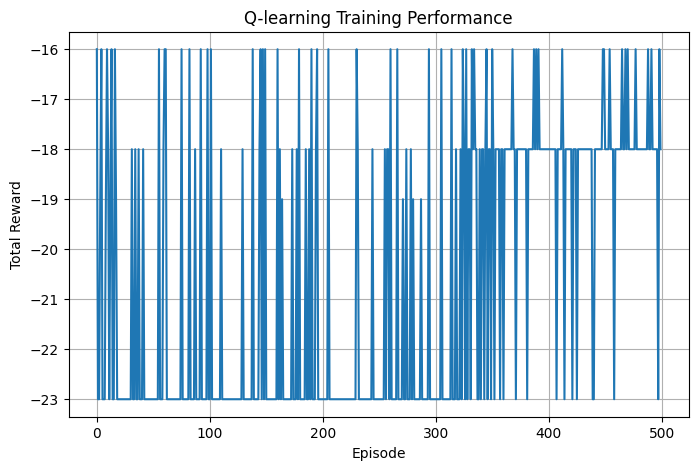

In [65]:
# Cell 11: Plot training performance

plt.figure(figsize=(8,5))
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-learning Training Performance")
plt.grid(True)
plt.show()

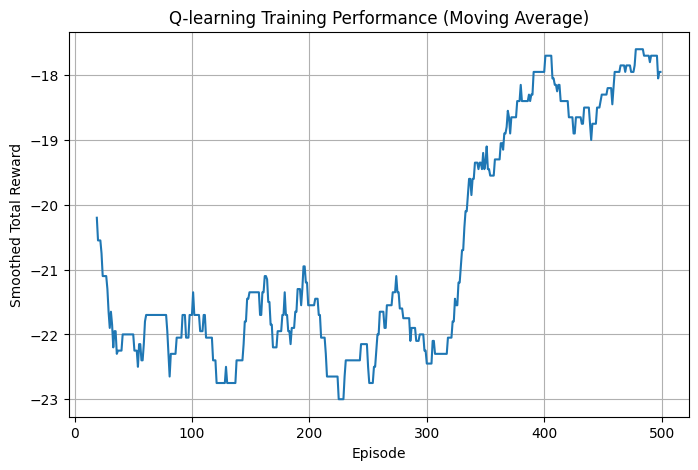

In [66]:
# Cell 12: Plot smoothed rewards

window = 20
smoothed_rewards = pd.Series(reward_history).rolling(window).mean()

plt.figure(figsize=(8,5))
plt.plot(smoothed_rewards)
plt.xlabel("Episode")
plt.ylabel("Smoothed Total Reward")
plt.title("Q-learning Training Performance (Moving Average)")
plt.grid(True)
plt.show()

In [67]:
# Cell 13: Extract best route from learned Q-values

def get_best_route():
    route = [START]
    state = START

    while state in Q and len(Q[state]) > 0:
        next_state = max(Q[state], key=Q[state].get)
        route.append(next_state)

        if next_state in LOTS and lot_valid(next_state):
            break

        state = next_state

    return route

best_route = get_best_route()
print("Learned best route:", " -> ".join(best_route))

Learned best route: S -> A -> C


In [68]:
# Cell 14: Scenario testing

def run_scenario_test():
    scenarios = {
        "normal": {},
        "traffic_spike": {('S', 'A'): 8},
        "lot_C_full": "C_full",
        "price_E_high": "E_expensive"
    }

In [69]:
# Cell 15: Main function to run baseline and RL

def run_baseline():
    lot, score = baseline_best_lot()
    return {
        "method": "Baseline",
        "best_lot": lot,
        "score": score
    }

In [70]:
# Cell 16: Main function to run Q-learning results

def run_q_learning():
    route = get_best_route()
    chosen_lot = route[-1]

    if chosen_lot in LOTS:
        score = total_cost(
            shortest_path_cost(START, chosen_lot),
            chosen_lot
        )
    else:
        score = None

    return {
        "method": "Q-Learning",
        "route": route,
        "best_lot": chosen_lot,
        "score": score
    }

In [71]:
# Cell 17: Run scenario tests and compare results

def run_scenario_test():
    results = []

    # save original values
    original_travel = TRAVEL_TIMES.copy()
    original_lots = {k: v.copy() for k, v in LOTS.items()}

    scenarios = [
        ("Normal", None),
        ("Traffic Spike", "traffic"),
        ("C Full", "full"),
        ("E Expensive", "price")
    ]

    for scenario_name, scenario_type in scenarios:

        # reset to original each time
        TRAVEL_TIMES.update(original_travel)

        for lot in LOTS:
            LOTS[lot].update(original_lots[lot])

        # apply scenario
        if scenario_type == "traffic":
            TRAVEL_TIMES[('S', 'A')] = 8

        elif scenario_type == "full":
            LOTS['C']['occupied'] = LOTS['C']['capacity']

        elif scenario_type == "price":
            LOTS['E']['price'] = 20

        baseline_result = run_baseline()
        train_q_learning()
        q_result = run_q_learning()

        results.append({
            "Scenario": scenario_name,
            "Baseline Lot": baseline_result["best_lot"],
            "Baseline Score": baseline_result["score"],
            "Q Lot": q_result["best_lot"],
            "Q Score": q_result["score"]
        })

    return pd.DataFrame(results)

In [72]:
# Cell 18: Run scenario tests and display results

scenario_results = run_scenario_test()
scenario_results

Lot C: drive=8, total score=26.0
Lot E: drive=10, total score=35.0
Lot C: drive=8, total score=26.0
Lot E: drive=10, total score=35.0
Lot E: drive=10, total score=35.0
Lot C: drive=8, total score=26.0
Lot E: drive=10, total score=55.0


,Scenario,Baseline Lot,Baseline Score,Q Lot,Q Score
0,Normal,C,26.0,C,26.0
1,Traffic Spike,C,26.0,C,26.0
2,C Full,E,35.0,E,35.0
3,E Expensive,C,26.0,C,26.0
